# Model Devoplopment

**Importing the dateset after the prepocessing..**

### **The Models:**

1. **Classification Model:** predicts whether the flight will be late more than 15 minuts or less.

   - Baseline Model: Logistic Regression
   - Other Models: XGBoost Classifier

2. **Regression Model:** predicts the delay time in minutes.
   - Baseline Model: Linear Regression
   - Other Models: Random Forest and XGBoost Regressor

# 1. Importing libraries and reading data

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



fill_path = "/content/Unconfirmed 775856.crdownload"

MainDF = pd.read_csv(fill_path)
MainDF.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,ArrTime,AirTime,...,DistanceGroup,DivAirportLandings,Delay,Delayed,Dep_mins,CRSDep_mins,DepDelay,Arr_mins,CRSArr_mins,ArrDelay
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1157.0,1256.0,38.0,...,1.0,0.0,0.0,0.0,717.0,722.0,0.0,776.0,784.0,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1157.0,1258.0,36.0,...,1.0,0.0,0.0,0.0,717.0,722.0,0.0,778.0,784.0,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1153.0,1302.0,40.0,...,1.0,0.0,7.0,0.0,713.0,722.0,0.0,782.0,784.0,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1150.0,1253.0,35.0,...,1.0,0.0,1.0,0.0,710.0,722.0,0.0,773.0,784.0,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1400.0,1355.0,1459.0,36.0,...,1.0,0.0,4.0,0.0,835.0,840.0,0.0,899.0,900.0,0.0


In [2]:
MainDF.shape

(633922, 41)

In [3]:
MainDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633922 entries, 0 to 633921
Data columns (total 41 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   FlightDate                               633922 non-null  object 
 1   Airline                                  633922 non-null  object 
 2   Origin                                   633922 non-null  object 
 3   Dest                                     633922 non-null  object 
 4   Cancelled                                633922 non-null  float64
 5   Diverted                                 633922 non-null  float64
 6   CRSDepTime                               633922 non-null  float64
 7   DepTime                                  633922 non-null  float64
 8   ArrTime                                  633922 non-null  float64
 9   AirTime                                  633922 non-null  float64
 10  CRSElapsedTime                  

In [4]:
MainDF["Delayed"].value_counts()

,count
Delayed,
0.0,596536
1.0,37385


In [5]:
MainDF.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'ArrTime', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'Operating_Airline',
       'OriginAirportID', 'OriginCityName', 'OriginState', 'OriginStateName',
       'DestAirportID', 'DestCityName', 'DestState', 'DestStateName',
       'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup',
       'DivAirportLandings', 'Delay', 'Delayed', 'Dep_mins', 'CRSDep_mins',
       'DepDelay', 'Arr_mins', 'CRSArr_mins', 'ArrDelay'],
      dtype='object')

# 2. Fix Imbalance using .sample() method
   - We took the length of Class 1 --> Delayed Flights
   - using .sample() we took a random sample of Class 0 --> On time flight or less than 15 min delay. which is in the size of calss 1, but subtracted 5000 samples from it.
   - Explain: To reduce class imbalance while maintaining higher sensitivity toward delayed flights.



In [6]:
# we wanna balance data
#1. Separate Minority and Majority Classes (DataFrames)
df_majority = MainDF[MainDF["Delayed"] == 0]
df_minority = MainDF[MainDF["Delayed"] == 1]

minority_size = len(df_minority) # OUR CHOICE
# 2. Undersample the Majority Class (sampling rows from the DataFrame)
df_majority_undersampled = df_majority.sample(n= (minority_size - 5000),
                replace=False, random_state=42)

# 3. Combine the Undersampled Majority with the Minority
delay_df_balanced = pd.concat([df_majority_undersampled, df_minority]) # the new df with all feature but balanced delayed

In [7]:
delay_df_balanced["Delayed"].value_counts()

,count
Delayed,
1.0,37385
0.0,32385


In [8]:
delay_df_balanced['DestStateName'].unique()


array(['Texas', 'Florida', 'Georgia', 'Illinois', 'Oregon', 'California',
       'Minnesota', 'Missouri', 'North Carolina', 'Rhode Island',
       'New York', 'Maryland', 'Pennsylvania', 'Alabama', 'Indiana',
       'Colorado', 'Alaska', 'Oklahoma',
       'U.S. Pacific Trust Territories and Possessions', 'Hawaii',
       'Nevada', 'Arizona', 'Michigan', 'Tennessee', 'Virginia', 'Idaho',
       'Massachusetts', 'Washington', 'Utah', 'Wisconsin', 'Kentucky',
       'New Jersey', 'Ohio', 'Louisiana', 'Montana', 'Mississippi',
       'New Hampshire', 'Nebraska', 'Maine', 'Connecticut',
       'South Carolina', 'Arkansas', 'Kansas', 'New Mexico', 'Iowa',
       'North Dakota', 'South Dakota', 'Puerto Rico', 'Wyoming',
       'West Virginia', 'Vermont', 'U.S. Virgin Islands'], dtype=object)

In [9]:
delay_df_balanced.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'ArrTime', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'Operating_Airline',
       'OriginAirportID', 'OriginCityName', 'OriginState', 'OriginStateName',
       'DestAirportID', 'DestCityName', 'DestState', 'DestStateName',
       'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup',
       'DivAirportLandings', 'Delay', 'Delayed', 'Dep_mins', 'CRSDep_mins',
       'DepDelay', 'Arr_mins', 'CRSArr_mins', 'ArrDelay'],
      dtype='object')

# 3. Feature Extraction and Setting Targets

In [10]:

#calssification model for is delayed AND REGRESSION TARGET
SELECTED_FEATURES = ['Airline','DepTime','CRSElapsedTime','Month','DayofMonth',
 'DayOfWeek','DestStateName','DistanceGroup','DepDelay', 'Delay', 'Delayed']

delay_df_balanced = delay_df_balanced[SELECTED_FEATURES]

# Create the feature matrix (X) and the target vector (y).
x_class = delay_df_balanced.drop(['Delay', 'Delayed'], axis=1)
y_class = delay_df_balanced['Delayed']


x_reg = delay_df_balanced.drop(['Delay', 'Delayed'], axis=1)
y_reg = delay_df_balanced['Delay']

# 4. Endcoding + Scaling + Transform:
  - splitting num from categorical
  - Preprocessing using a pipline

In [11]:
# splitting num from categorical
numeric_features = ['DepTime','CRSElapsedTime','Month','DayofMonth',
                    'DayOfWeek','DistanceGroup','DepDelay']

categorical_features = ['Airline','DestStateName']

# Preprocessing using a pipline
preprocess = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features),
                  ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)]
)

#5.  First Model: Classify whether if its more than 15 minutes delay or not

### 1. Baseline: Classification - Logistic Regression model

In [13]:
model = Pipeline(steps=[('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=10000))
])

# Train-test split
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_class, y_class, test_size=0.2, random_state=42)

# Split Train into Train-Validation
x_train_c, x_val_c, y_train_c, y_val_c = train_test_split(
    x_train_c, y_train_c, test_size=0.25, random_state=42, stratify=y_train_c)


# 7. Train
model.fit(x_train_c, y_train_c)


print("Train shape: ", x_train_c.shape)
print("Val shape: ", x_val_c.shape)
print("Test shape: ", x_test_c.shape)

Train shape:  (41862, 9)
Val shape:  (13954, 9)
Test shape:  (13954, 9)


In [15]:
# 8. Evaluate
print("Accuracy:", model.score(x_test_c, y_test_c))

Accuracy: 0.6335817686684821


### Logistic Regression Accuracy scores for our classification

In [16]:
y_pred_c_lr = model.predict(x_test_c)

# Print classification report
print(classification_report(y_test_c, y_pred_c_lr))

              precision    recall  f1-score   support

         0.0       0.63      0.51      0.56      6456
         1.0       0.64      0.74      0.69      7498

    accuracy                           0.63     13954
   macro avg       0.63      0.62      0.62     13954
weighted avg       0.63      0.63      0.63     13954



### Logistic Regression predction vs test for 10 samples

In [17]:
results_df = pd.DataFrame({
    "Actual Delay": y_test_c.values[:10],
    "Predicted Delay": y_pred_c_lr[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)


First 10 predictions:

   Actual Delay  Predicted Delay
0           0.0              1.0
1           1.0              1.0
2           1.0              0.0
3           0.0              0.0
4           1.0              1.0
5           1.0              1.0
6           1.0              1.0
7           1.0              0.0
8           1.0              1.0
9           0.0              0.0




---


### 2. Second classification models:XGBClassifier



In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', XGBClassifier(
        n_estimators = 500,
        learning_rate = 0.05,
        max_depth = 5,
        min_child_weight = 3,
        subsample = 0.8,
        colsample_bytree = 0.7,
        gamma = 0.1,
        reg_lambda = 1.0,       # L2
        reg_alpha = 0.1,        # L1
        eval_metric = "logloss"
    ))
])

xgb_model.fit(x_train_c, y_train_c)

y_pred_xgb = xgb_model.predict(x_test_c)

print("XGBoost Classification Report:")
print(classification_report(y_test_c, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.59      0.63      6456
         1.0       0.68      0.76      0.72      7498

    accuracy                           0.68     13954
   macro avg       0.68      0.68      0.68     13954
weighted avg       0.68      0.68      0.68     13954



### XGBoost Classifier predction vs test for 10 samples

In [19]:
results_df = pd.DataFrame({
    "Actual Delay": y_test_c.values[:10],
    "Predicted Delay": y_pred_xgb[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)


First 10 predictions:

   Actual Delay  Predicted Delay
0           0.0                1
1           1.0                1
2           1.0                0
3           0.0                0
4           1.0                1
5           1.0                0
6           1.0                1
7           1.0                0
8           1.0                0
9           0.0                0


# In conclusion: F1 Score in GXBoost Classifier gave us higher score.

# 6. Second Model: Regression Models to predict delay time in minuts

### 1. Baseline Model: Linear regression   

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# using a pipeline and preprocessing pipeline used before
reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

In [21]:
# Train-Test Split
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42)

# Train-Validation Split
x_train_r, x_val_r, y_train_r, y_val_r = train_test_split(
    x_train_r, y_train_r, test_size=0.25, random_state=42)

print("Train shape: ", x_train_c.shape)
print("Val shape: ", x_val_c.shape)
print("Test shape: ", x_test_c.shape)

# 6. Train
reg_model.fit(x_train_r, y_train_r)

# 7. Predict
y_pred_r = reg_model.predict(x_test_r)

Train shape:  (41862, 9)
Val shape:  (13954, 9)
Test shape:  (13954, 9)


### Loss function results for baseline model (linear regression) and oredicted vs. actual 10 samples

In [28]:
# 8. Evaluate
mae_lr= mean_absolute_error(y_test_r, y_pred_r)
mse_lr = mean_squared_error(y_test_r, y_pred_r)
rmse_lr = mse_lr ** 0.5

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

# 5. Show first 10 predictions
results_df = pd.DataFrame({
    "Actual Delay": y_test_r.values[:10],
    "Predicted Delay": y_pred_r[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)

MAE: 12.411621471335279
RMSE: 17.06472390391284

First 10 predictions:

   Actual Delay  Predicted Delay
0           0.0        18.944927
1          38.0        19.639754
2          17.0         8.954362
3           7.0         9.167956
4          49.0        15.374763
5          20.0        15.191327
6          15.0        15.300023
7          16.0        11.246513
8          59.0        18.272326
9           0.0         5.819238


### 2. Second Model: Random Forest Regressor

In [25]:
from sklearn.ensemble import RandomForestRegressor


# parameters set to meet the defults or near the defults which suits our dataset and cae
reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ))
])

### Loss function results for baseline model (random forest regressor) and oredicted vs. actual 10 samples

In [26]:
reg_model.fit(x_train_r, y_train_r)

# 3. Predict
y_pred_r_rf = reg_model.predict(x_test_r)

# 4. Evaluate
mae = mean_absolute_error(y_test_r, y_pred_r_rf)
rmse = mean_squared_error(y_test_r, y_pred_r_rf) ** 0.5

print("Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse)

# 5. Show first 10 predictions
results_df = pd.DataFrame({
    "Actual Delay": y_test_r.values[:10],
    "Predicted Delay": y_pred_r_rf[:10]
})

print("\nFirst 10 predictions:\n")
print(results_df)

Random Forest Results:
MAE: 11.422573215735857
RMSE: 15.781347593165016

First 10 predictions:

   Actual Delay  Predicted Delay
0           0.0        20.562125
1          38.0        25.989178
2          17.0         9.687883
3           7.0        14.934643
4          49.0        23.259639
5          20.0        12.235836
6          15.0        17.043570
7          16.0         3.956448
8          59.0        14.922252
9           0.0         1.455802


### 3. Third Model: XGBoost Regressor

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

xgb_reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', XGBRegressor(
        n_estimators = 500,
        learning_rate = 0.05,
        max_depth = 5,
        min_child_weight = 3,
        subsample = 0.8,
        colsample_bytree = 0.7,
        gamma = 0.1,
        reg_lambda = 1.0,       # L2
        reg_alpha = 0.1,        # L1
        eval_metric = "rmse" #for regression
    ))
])

xgb_reg_model.fit(x_train_r, y_train_r)

y_pred_xgb_r = xgb_reg_model.predict(x_test_r)

mae_xgb = mean_absolute_error(y_test_r, y_pred_xgb_r)
rmse_xgb = mean_squared_error(y_test_r, y_pred_xgb_r) ** 0.5

print("XGBoost Regressor Results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

# Show first 10 predictions
results_df_xgb = pd.DataFrame({
    "Actual Delay": y_test_r.values[:10],
    "Predicted Delay": y_pred_xgb_r[:10]
})

print("\nFirst 10 predictions (XGBoost Regressor):\n")
print(results_df_xgb)

XGBoost Regressor Results:
MAE: 11.516929187938588
RMSE: 15.880588962319731

First 10 predictions (XGBoost Regressor):

   Actual Delay  Predicted Delay
0           0.0        23.603533
1          38.0        33.374313
2          17.0         9.956673
3           7.0        10.833879
4          49.0        23.138813
5          20.0        10.736141
6          15.0        21.379391
7          16.0         6.264559
8          59.0        12.030984
9           0.0         4.845932


# 7. Comparasion

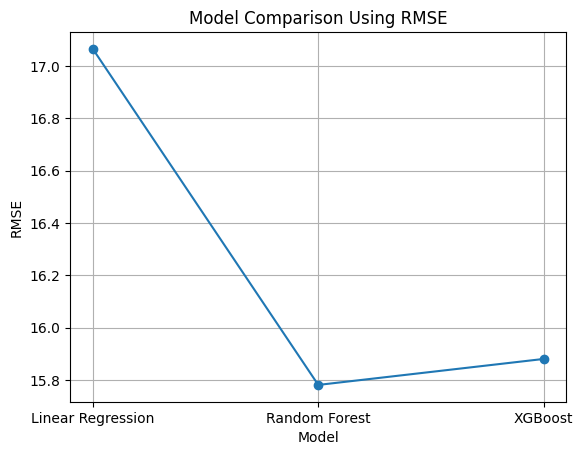

In [32]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_values = [rmse_lr, rmse, rmse_xgb]

plt.figure()
plt.plot(models, rmse_values, marker='o')
plt.title('Model Comparison Using RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


We see that XGBoost is best combination of performance + Accuracy